### Importação dos dados



In [192]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja = pd.read_csv(url)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

loja.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38


#1. Análise do faturamento



In [193]:
dados = [loja, loja2, loja3, loja4]

faturamento_por_loja = []

for dado in dados:
  faturamento = dado['Preço'].sum()
  faturamento_por_loja.append(faturamento)

faturamento_por_loja

[np.float64(1534509.12),
 np.float64(1488459.06),
 np.float64(1464025.03),
 np.float64(1384497.58)]

# 2. Vendas por Categoria

In [194]:
dados = [loja, loja2, loja3, loja4]

vendas_por_categoria = []

for dado in dados:
  vendas = dado.groupby('Categoria do Produto')['Produto'].count()
  vendas = vendas.sort_values(ascending=False)
  vendas_por_categoria.append(vendas)

vendas_por_categoria

[Categoria do Produto
 moveis                   465
 eletronicos              448
 brinquedos               324
 eletrodomesticos         312
 esporte e lazer          284
 instrumentos musicais    182
 livros                   173
 utilidades domesticas    171
 Name: Produto, dtype: int64,
 Categoria do Produto
 moveis                   442
 eletronicos              422
 brinquedos               313
 eletrodomesticos         305
 esporte e lazer          275
 instrumentos musicais    224
 livros                   197
 utilidades domesticas    181
 Name: Produto, dtype: int64,
 Categoria do Produto
 moveis                   499
 eletronicos              451
 brinquedos               315
 eletrodomesticos         278
 esporte e lazer          277
 livros                   185
 instrumentos musicais    177
 utilidades domesticas    177
 Name: Produto, dtype: int64,
 Categoria do Produto
 moveis                   480
 eletronicos              451
 brinquedos               338
 esporte e l

# 3. Média de Avaliação das Lojas


In [195]:
dados = [loja, loja2, loja3, loja4]

media_avaliacao = []

for dado in dados:
  media_loja = dado['Avaliação da compra'].mean()
  media_avaliacao.append(media_loja)

media_avaliacao

[np.float64(3.976685036032217),
 np.float64(4.037303942348453),
 np.float64(4.048325561678677),
 np.float64(3.9957591178965224)]

# 4. Produtos Mais e Menos Vendidos

In [196]:
dados = [loja, loja2, loja3, loja4]

produtos_mais_vendidos = {}
produtos_menos_vendidos = {}

for i, dado in enumerate(dados):
  nome_loja = f"Loja {i+1}"

  contagem_produtos = dado['Produto'].value_counts()
  produtos_mais_vendidos[nome_loja] = contagem_produtos.head(3)
  produtos_menos_vendidos[nome_loja] = contagem_produtos.tail(3)

  print("MAIS VENDIDOS:")
  display(produtos_mais_vendidos[nome_loja])

  print("MENOS VENDIDOS:")
  display(produtos_menos_vendidos[nome_loja])

MAIS VENDIDOS:


,count
Produto,
Micro-ondas,60
TV Led UHD 4K,60
Guarda roupas,60


MENOS VENDIDOS:


,count
Produto,
Panela de pressão,35
Headset,33
Celular ABXY,33


MAIS VENDIDOS:


...

,count
Produto,
Mochila,36
Micro-ondas,36
Blocos de montar,35


MAIS VENDIDOS:


,count
Produto,
Cama box,62
Faqueiro,59
Dashboards com Power BI,56


MENOS VENDIDOS:


,count
Produto,
Violão,37
Guarda roupas,34
Guitarra,33


# 5. Frete Médio por Loja

In [197]:
dados = [loja, loja2, loja3, loja4]

media_frete = []

for dado in dados:
  media_loja_frete = dado['Frete'].mean()
  media_frete.append(media_loja_frete)

media_frete

[np.float64(34.69180491551149),
 np.float64(33.62194065817927),
 np.float64(33.07446427411743),
 np.float64(31.278997081841727)]

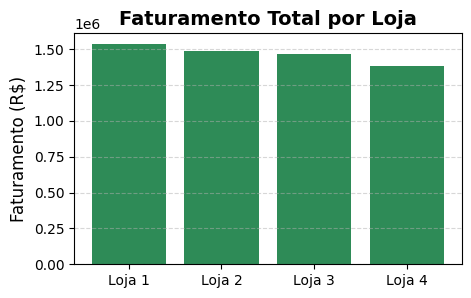

In [198]:
nomes_lojas = ['Loja 1', 'Loja 2', 'Loja 3', 'Loja 4']

plt.figure(figsize=(5, 3))
plt.bar(nomes_lojas, faturamento_por_loja, color='seagreen')

plt.title('Faturamento Total por Loja', fontsize=14, fontweight='bold')
plt.ylabel('Faturamento (R$)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

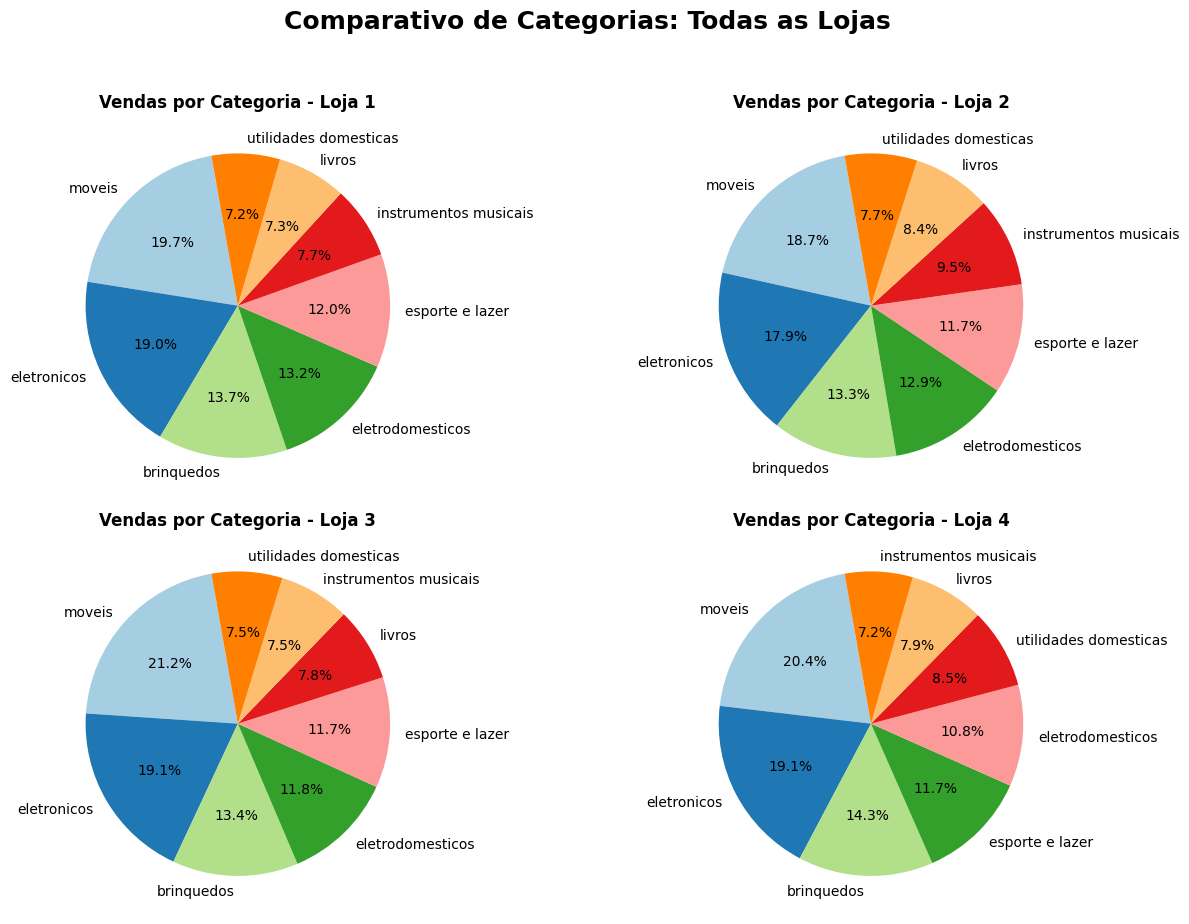

In [216]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

axes = axes.flatten()

for i, categorias_loja in enumerate(vendas_por_categoria):
    ax = axes[i]
    nome_loja = f"Loja {i+1}"

    ax.pie(categorias_loja.values,
           labels=categorias_loja.index,
           autopct='%1.1f%%',
           startangle=100,
           colors=plt.cm.Paired.colors,
           textprops={'fontsize': 10})

    ax.set_title(f'Vendas por Categoria - {nome_loja}', fontsize=12, fontweight='bold')

plt.suptitle('Comparativo de Categorias: Todas as Lojas', fontsize=18, fontweight='bold', y=0.95)

plt.tight_layout(rect=[0, 0.03, 1, 0.92])

plt.show()

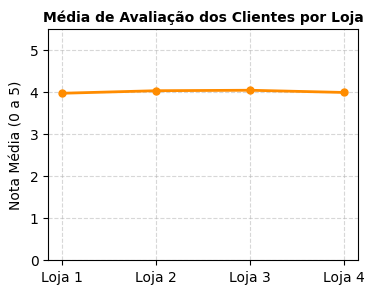

In [200]:
plt.figure(figsize=(4, 3))
plt.plot(nomes_lojas, media_avaliacao, color='darkorange', marker='o', linewidth=2, markersize=5)

plt.title('Média de Avaliação dos Clientes por Loja', fontsize=10, fontweight='bold')
plt.ylabel('Nota Média (0 a 5)', fontsize=10)
plt.ylim(0, 5.5)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

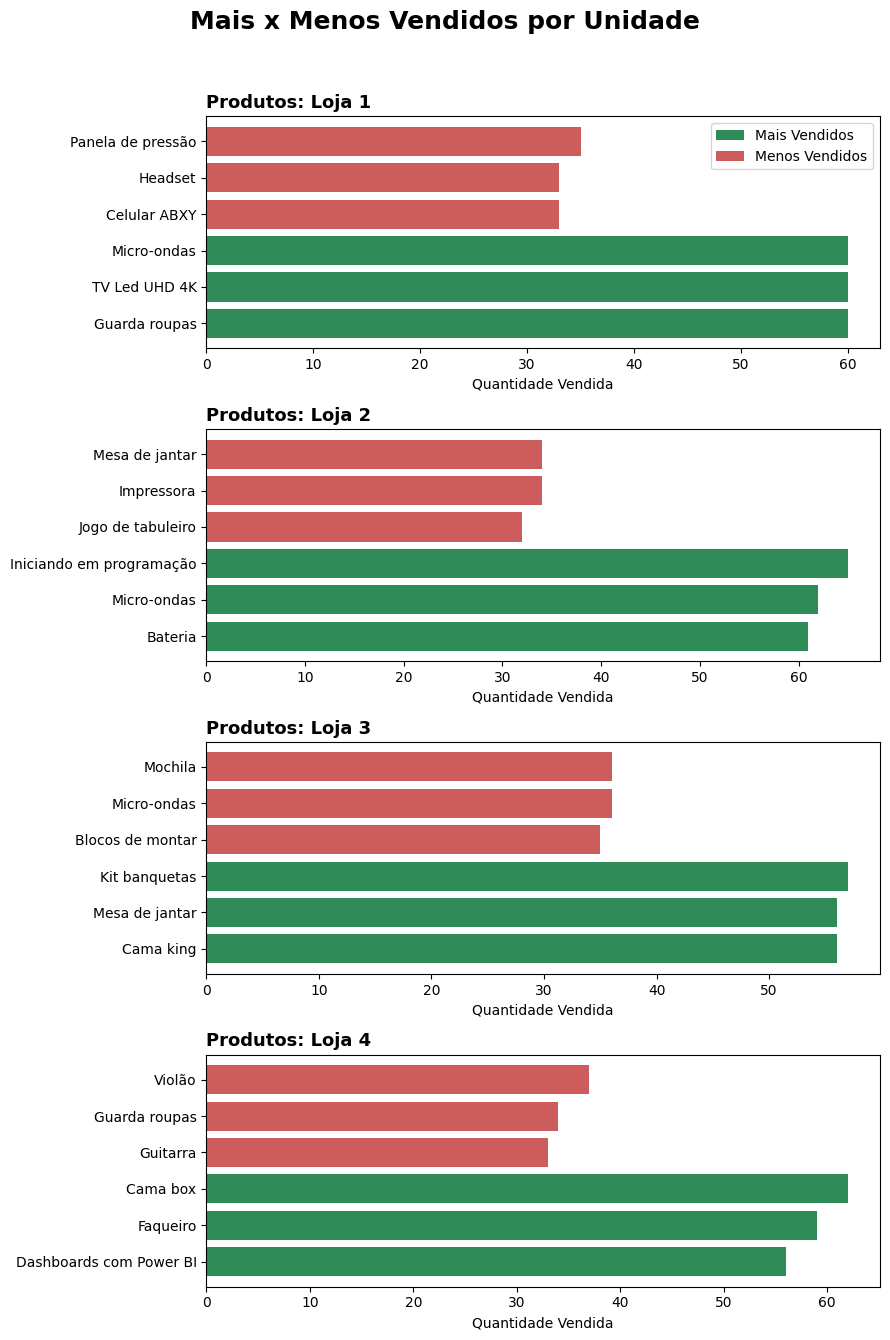

In [219]:
fig, axes = plt.subplots(4, 1, figsize=(9, 15))

fig.suptitle('Mais x Menos Vendidos por Unidade',
             fontsize=18, fontweight='bold', y=0.92)

lista_lojas = list(produtos_mais_vendidos.keys())

for i, nome_loja in enumerate(lista_lojas):
    ax = axes[i]

    mais = produtos_mais_vendidos[nome_loja]
    menos = produtos_menos_vendidos[nome_loja]

    ax.barh(mais.index[::-1], mais.values[::-1], color='seagreen', label='Mais Vendidos')
    ax.barh(menos.index[::-1], menos.values[::-1], color='indianred', label='Menos Vendidos')

    ax.set_title(f'Produtos: {nome_loja}', fontsize=13, fontweight='bold', loc='left')
    ax.set_xlabel('Quantidade Vendida')

    if i == 0:
        ax.legend(loc='upper right', fontsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.90])

plt.show()

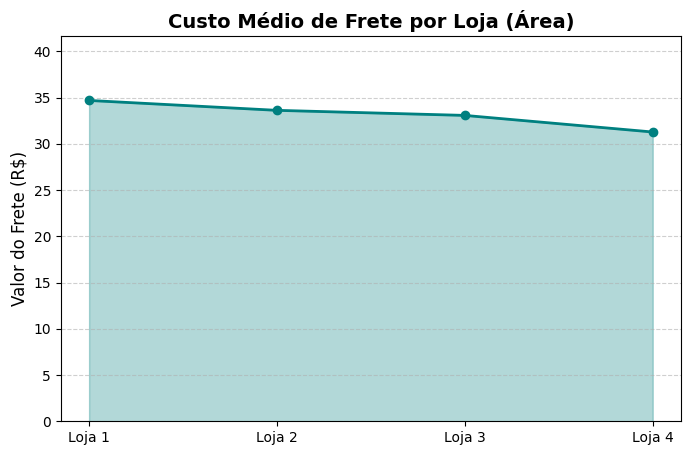

In [202]:
nomes_lojas = ['Loja 1', 'Loja 2', 'Loja 3', 'Loja 4']

plt.figure(figsize=(8, 5))

plt.plot(nomes_lojas, media_frete, color='teal', marker='o', linewidth=2)

plt.fill_between(nomes_lojas, media_frete, color='teal', alpha=0.3)

plt.title('Custo Médio de Frete por Loja (Área)', fontsize=14, fontweight='bold')
plt.ylabel('Valor do Frete (R$)', fontsize=12)

plt.ylim(0, max(media_frete) * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

# Relatório Final

## 1. Introdução
Este relatório sintetiza o desempenho das unidades 1, 2, 3 e 4, fundamentando-se em cinco pilares estratégicos: faturamento, custos de frete, satisfação do cliente, giro de produtos (mais e menos vendidos) e desempenho por categoria. Esta análise visa otimizar o portfólio de negócios do Senhor João, identificando a unidade com menor retorno sobre o investimento para uma possível descontinuação.

## 2. Desenvolvimento
### Faturamento por Loja
Conforme demonstrado no Gráfico de Barras de Faturamento, a Loja 1 é a líder absoluta de receita, superando a marca de R$ 1,5 milhão. Em contrapartida, a Loja 4 apresenta o faturamento mais baixo do grupo.

Existe uma diferença de quase R$ 150 mil entre a melhor e a pior loja, indicando que a Loja 4 tem uma participação de mercado significativamente menor.

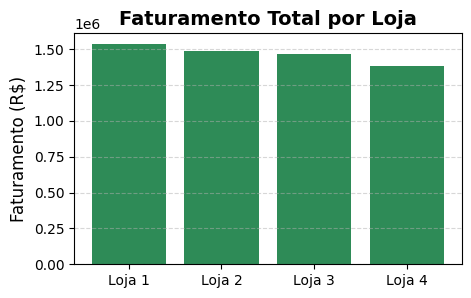

### Destaques de Vendas
Os produtos que mais vendem nessa loja ainda vendem menos do que os produtos "comuns" das outras lojas. Isso mostra que a Loja 4 não tem um "produto campeão" (aquele que todo mundo procura) para manter o negócio funcionando bem.

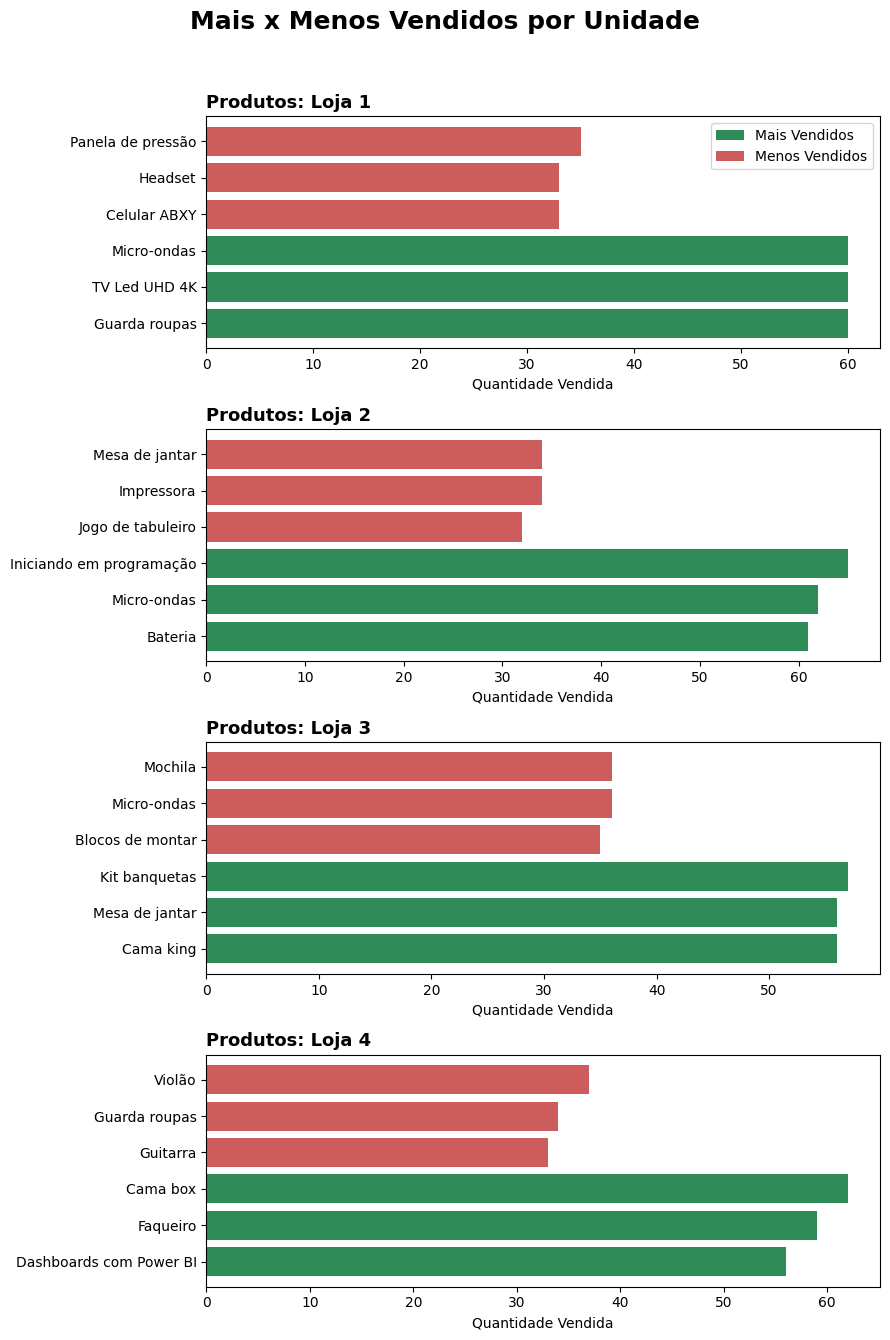

### Avaliações do Cliente
A Loja 3 é a favorita do público, mantendo a maior média de satisfação.

A Loja 4 e a Loja 1 disputam as menores notas. No caso da Loja 1, a nota baixa é mitigada pelo alto volume de vendas, mas na Loja 4, a nota baixa reforça a necessidade de desinvestimento.

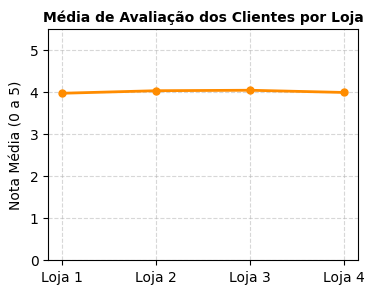

### Categorias
A categoria de Móveis é o motor de vendas da rede.

Na Loja 4, o desempenho de categorias secundárias é ineficiente e os produtos "Menos Vendidos" possuem um volume de saída muito abaixo da média das outras filiais, o que sugere capital preso em estoque.

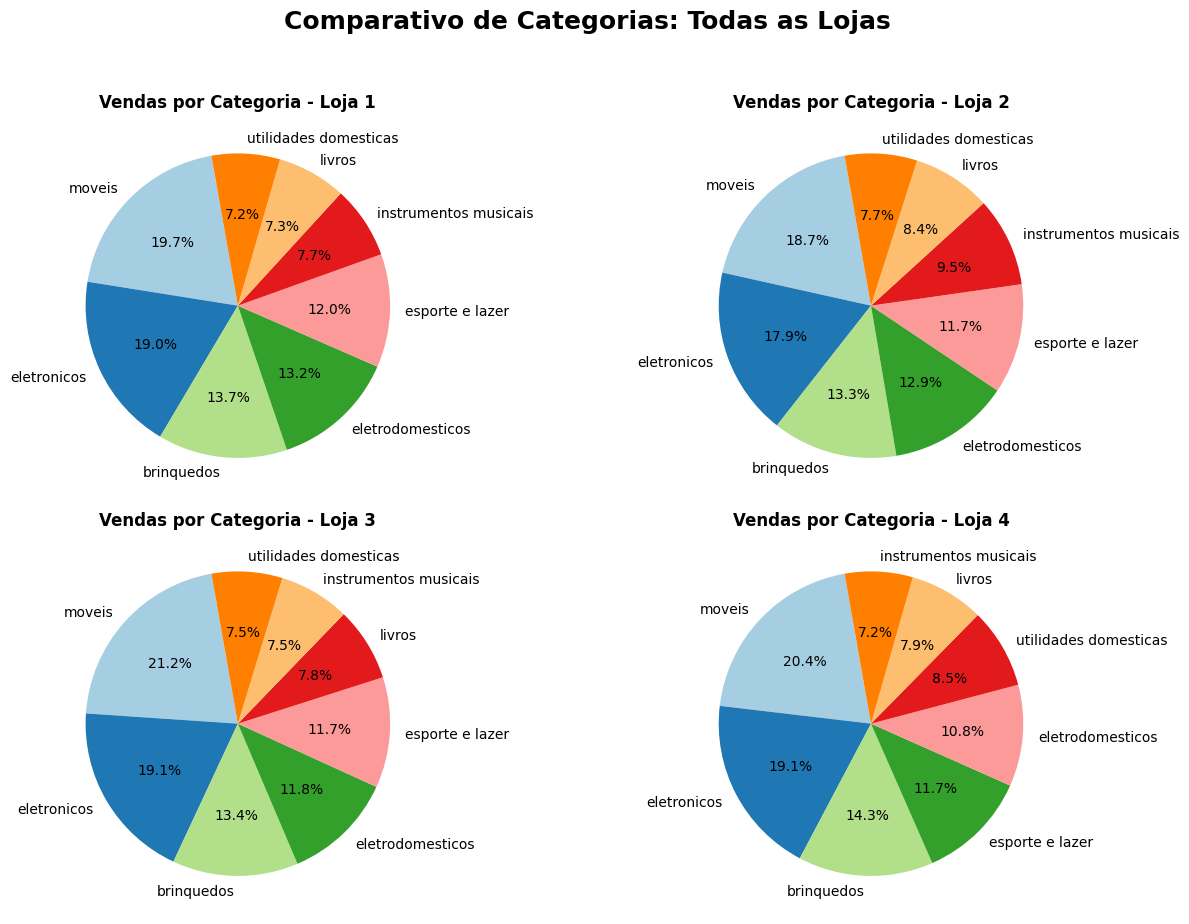

### Eficiência Logística - Frete
A Loja 4 possui o frete médio mais barato.
Se a loja tem o frete mais acessível e, mesmo assim, vende menos que todas as outras, o problema não é o custo de entrega, mas sim o desinteresse do público local ou a ineficiência de produtos ofertado naquela região.

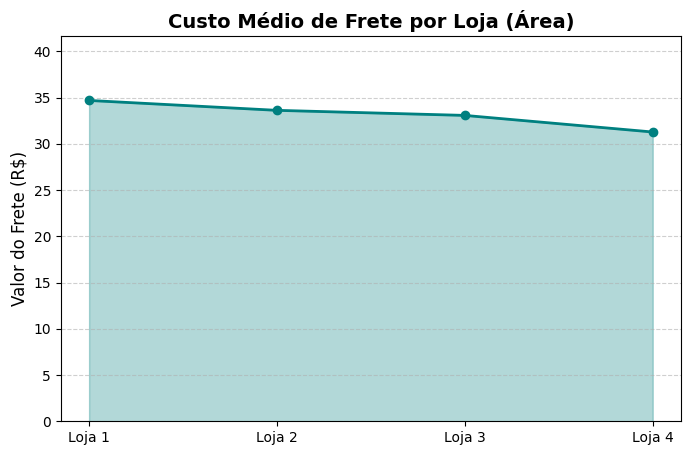

## 3. Conclusão e Recomendação Final
Com base em todos os indicadores, a recomendação estratégica para o Senhor João é a venda da Loja 4.

* Pior Performance de Vendas: É a unidade com menor faturamentonda rede.
* Incapacidade de Conversão: Mesmo com a vantagem competitiva de ter o frete mais barato, a unidade não consegue converter essa economia em volume de vendas.
* Baixa Satisfação: A nota de avaliação inferior indica problemas operacionais ou de percepção de marca que exigiriam alto investimento para correção.
* Otimização de Recursos: A venda da Loja 4 permitirá que o Senhor João aporte capital na Loja 1 (para reduzir o custo de frete que é alto, mas vende muito) ou na Loja 3 (para expandir o modelo que possui alta satisfação).